# MICROGRAD!!! #

In [11]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [36]:
class Value:

  def __init__(self, data, children=(), op='', label=''):
    self.data = data
    self.prev = set(children)
    self.op = op
    self.label = label
    self.grad = 0.0
    self.setChildrenGrad = lambda: None

  def __repr__(self):
    return f"Value(data={self.data}, grad={self.grad})"

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')
    def setChildrenGrads():
      self.grad += 1.0 * out.grad
      other.grad += 1.0 * out.grad
    out.setChildrenGrad = setChildrenGrads
    return out

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')
    def setChildrenGrads():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad
    out.setChildrenGrad = setChildrenGrads
    return out

  def tanh(self):
    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')
    def setChildrenGrads():
      self.grad += (1 - t**2) * out.grad
    out.setChildrenGrad = setChildrenGrads
    return out

  def exp(self):
    x = self.data
    out = Value(math.exp(x), (self, ), 'exp')
    def setChildrenGrads():
      self.grad += out.data * out.grad
    out.setChildrenGrad = setChildrenGrads
    return out

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int and float for now"
    out = Value(self.data**other, (self, ), f'pow {other}')
    def setChildrenGrads():
      self.grad += other * (self.data ** (other - 1)) * out.grad
    out.setChildrenGrad = setChildrenGrads
    return out

  def __rmul__(self, other):
    return self * other

  def __truediv__(self, other):
    return self * other**-1

  def __neg__(self):
    return self * -1

  def __sub__(self, other):
    return self + (-other)

  def __radd__(self, other):
    return self + other

  def backward(self):
    topo = []
    visited = set()
    def build_topo(v):
      if v not in visited:
        visited.add(v)
        for child in v.prev:
          build_topo(child)
        topo.append(v)
    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo):
      node.setChildrenGrad()

In [13]:
a = Value(2.0, label='a')
b = Value(-3.0, label='b')
c = Value(10.0, label='c')
e = a*b; e.label = 'e'
d = e + c; d.label = 'd'
f = Value(-2.0, label='f')
L = d * f; L.label = 'L'
L

Value(data=-8.0)

In [14]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v.prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n.op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n.op, label = n.op)
      # and connect this node to it
      dot.edge(uid + n.op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2.op)

  return dot

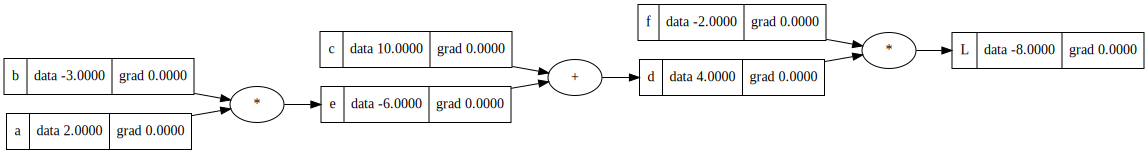

In [15]:
draw_dot(L)

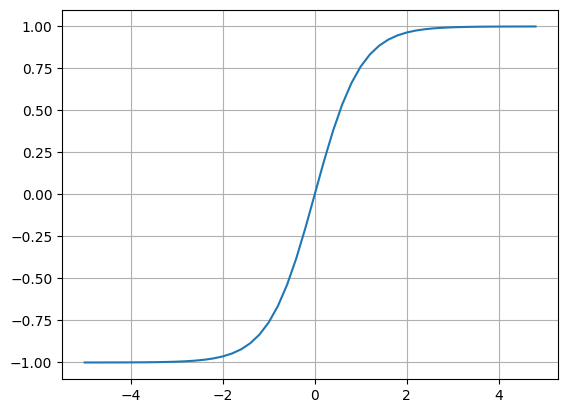

In [16]:
plt.plot(np.arange(-5,5,0.2), np.tanh(np.arange(-5,5,0.2))); plt.grid();

In [17]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
o = n.tanh(); o.label = 'o'

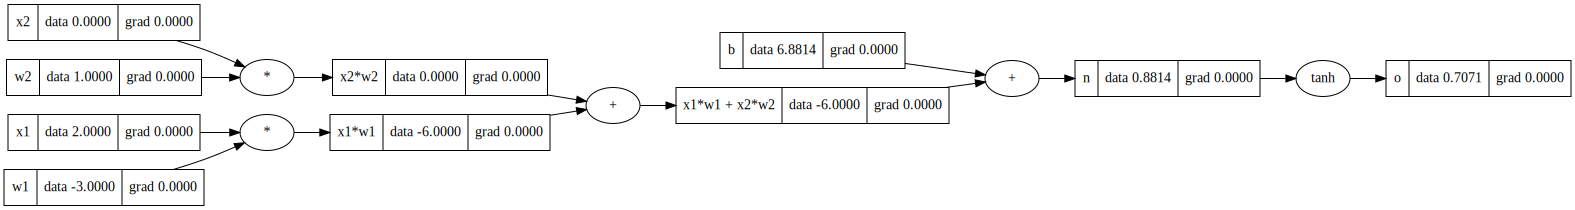

In [18]:
draw_dot(o)

In [19]:
topo = []
visited = set()
def build_topo(v):
  if v not in visited:
    visited.add(v)
    for child in v.prev:
      build_topo(child)
    topo.append(v)
build_topo(o)
topo

[Value(data=6.881373587019543),
 Value(data=-3.0),
 Value(data=2.0),
 Value(data=-6.0),
 Value(data=0.0),
 Value(data=1.0),
 Value(data=0.0),
 Value(data=-6.0),
 Value(data=0.8813735870195432),
 Value(data=0.7071067811865476)]

In [20]:
o.backward()

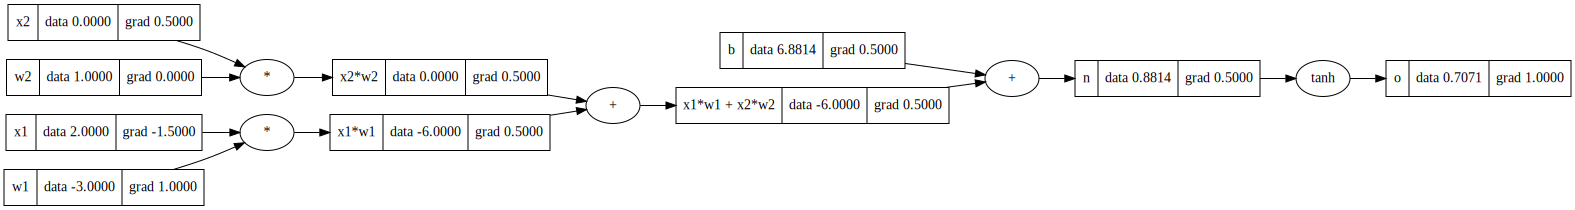

In [21]:
draw_dot(o)

In [22]:
# inputs x1,x2
x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')
# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')
# bias of the neuron
b = Value(6.8813735870195432, label='b')
# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'
# ----
e = (2*n).exp(); e.label = 'e'
o = (e - 1) / (e + 1);
# ----
o.label = 'o'
o.backward()

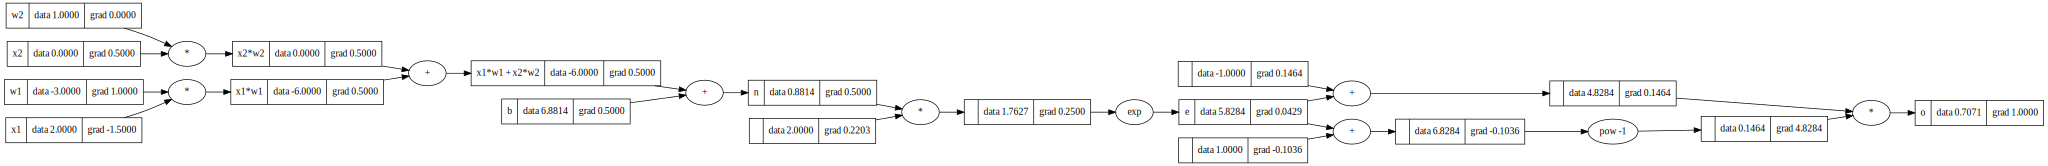

In [23]:
draw_dot(o)

# NEURAL NETWORK CREATION #

In [37]:
import random
class Neuron:

  def __init__(self, in_connections): # A neuron has only single output
    self.w = [Value(random.uniform(-1,1)) for _ in range(in_connections)]
    self.b = Value(random.uniform(-1,1))

  def __call__(self, x):
    activations = sum((wi * xi for wi, xi in zip(self.w,x)), self.b) # Gets inputs and calculates output using weight and bias
    out = activations.tanh() # Output of the neuron
    return out

  def parameters(self): # Parameter list of the neuron
    return self.w + [self.b]

In [38]:
class Layer:

  def __init__(self, in_connections, out_connections): # Create a stack of unconnected neurons
    self.neurons = [Neuron(in_connections) for _ in range(out_connections)]

  def __call__(self, x):
    outs = [n(x) for n in self.neurons] # Pass inputs to the neurons and calculate output for each
    return outs[0] if len(outs) == 1 else outs  # Return the list of outputs of the layer

  def parameters(self): # Parameter list of the layer
    return [p for neuron in self.neurons for p in neuron.parameters()]

In [49]:
class MultiLayerPerceptron:

  def __init__(self, num_of_input_params, layers_info_array): # Create unconnected layers
    sz = [num_of_input_params] + layers_info_array # Total number of layers including the input array
    self.layers = [Layer(sz[i], sz[i+1]) for i in range(len(layers_info_array))] # The sz[0] is only for telling the first layer how many inputs/weights to initialize for

  def __call__(self, x):
    for layer in self.layers:
      x = layer(x) # Connection between layers and neurons happen here. The output of previous layer is used as the input to the new layer
    return x # The final layer output

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


In [43]:
x = [2.0, 3.0, -1.0]
n = MultiLayerPerceptron(3,[4,4,1]) # A MLP with 3 inputs i.e. x values and 3 layers including the final output as last layer
o = n(x) # Getting the output of the final layer i.e. the final output
o

Value(data=-0.41744177463419807, grad=0.0)

In [44]:
n.parameters()

[Value(data=-0.5248277767765699, grad=0.0),
 Value(data=0.2670614955209063, grad=0.0),
 Value(data=0.2633775739581694, grad=0.0),
 Value(data=0.5507218556809748, grad=0.0),
 Value(data=0.03082038571888379, grad=0.0),
 Value(data=0.43150622296045027, grad=0.0),
 Value(data=-0.40222346580558477, grad=0.0),
 Value(data=-0.5260484305542907, grad=0.0),
 Value(data=-0.6993124855962192, grad=0.0),
 Value(data=0.2214711240104419, grad=0.0),
 Value(data=0.7416218779659272, grad=0.0),
 Value(data=-0.07304232586020487, grad=0.0),
 Value(data=0.6549714301141338, grad=0.0),
 Value(data=-0.629297962738492, grad=0.0),
 Value(data=0.46303337185634064, grad=0.0),
 Value(data=-0.9673482776199471, grad=0.0),
 Value(data=0.747890127791649, grad=0.0),
 Value(data=0.05064756421673211, grad=0.0),
 Value(data=-0.20612055451311484, grad=0.0),
 Value(data=-0.6107398679342804, grad=0.0),
 Value(data=-0.46897752421271277, grad=0.0),
 Value(data=-0.8115722105602654, grad=0.0),
 Value(data=-0.04746857365291812, gra

The above example is a single data set and which we found the value of -0.417. Now if this was a test data set and the known output was let's say +1.65. Then using backpropogation, we would find the gradient of each of the parameters and then would modify in such a way that they contribute towards the answer.

In [45]:
# let's backpropogate and find the gradients
o.backward()

In [46]:
n.parameters()

[Value(data=-0.5248277767765699, grad=1.1352496093999753),
 Value(data=0.2670614955209063, grad=1.702874414099963),
 Value(data=0.2633775739581694, grad=-0.5676248046999877),
 Value(data=0.5507218556809748, grad=0.5676248046999877),
 Value(data=0.03082038571888379, grad=0.09543642455008779),
 Value(data=0.43150622296045027, grad=0.1431546368251317),
 Value(data=-0.40222346580558477, grad=-0.04771821227504389),
 Value(data=-0.5260484305542907, grad=0.04771821227504389),
 Value(data=-0.6993124855962192, grad=0.0816990542696601),
 Value(data=0.2214711240104419, grad=0.12254858140449015),
 Value(data=0.7416218779659272, grad=-0.04084952713483005),
 Value(data=-0.07304232586020487, grad=0.04084952713483005),
 Value(data=0.6549714301141338, grad=-0.030725239740736477),
 Value(data=-0.629297962738492, grad=-0.04608785961110472),
 Value(data=0.46303337185634064, grad=0.015362619870368239),
 Value(data=-0.9673482776199471, grad=-0.015362619870368239),
 Value(data=0.747890127791649, grad=0.00748

By tweaking these gradients we can reach the desired output of +1.65 and then use the value of these parameters for real life cases. This is called training.

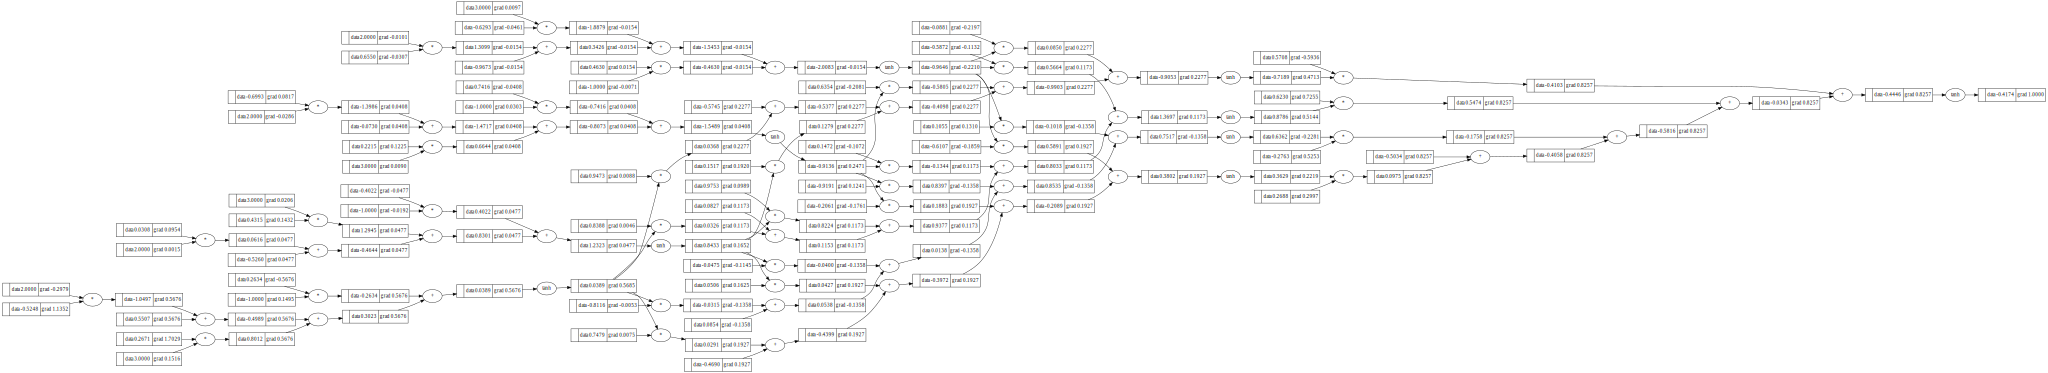

In [48]:
draw_dot(o)

### Using Gradient Descent ###

In [58]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets
n = MultiLayerPerceptron(3,[4,4,1])

In [70]:
for k in range(50): # Doing 50 steps of gradient descent

  # forward pass
  ypred = [n(x) for x in xs]
  loss = sum((yout - ygt)**2 for ygt, yout in zip(ys, ypred)) # Taking the mean squared error for loss, works fine for this case

  # backward pass
  for p in n.parameters():
    p.grad = 0.0 # VERY VERY BASIC MISTAKE POINT. Always set the param grad to 0 else it adds to the previous grad
  loss.backward()

  # update
  for p in n.parameters():
    p.data += -0.1 * p.grad # 0.1 is the learning rate. The sign is negative as we need to MINIMIZE the loss

  print(k, loss.data)

0 0.0006160625384218344
1 0.0006146172833331834
2 0.0006131786277538984
3 0.0006117465269552021
4 0.0006103209366099774
5 0.0006089018127882471
6 0.0006074891119527986
7 0.0006060827909548125
8 0.0006046828070295038
9 0.0006032891177919076
10 0.0006019016812326698
11 0.0006005204557139232
12 0.000599145399965158
13 0.00059777647307926
14 0.0005964136345084402
15 0.0005950568440603761
16 0.0005937060618943059
17 0.0005923612485172101
18 0.0005910223647800346
19 0.0005896893718739624
20 0.000588362231326718
21 0.0005870409049989781
22 0.0005857253550807275
23 0.0005844155440877798
24 0.0005831114348582493
25 0.0005818129905490888
26 0.0005805201746327407
27 0.0005792329508937305
28 0.0005779512834253352
29 0.0005766751366263665
30 0.0005754044751978928
31 0.000574139264140044
32 0.000572879468748884
33 0.000571625054613271
34 0.0005703759876118106
35 0.0005691322339097833
36 0.0005678937599561888
37 0.0005666605324807633
38 0.0005654325184910459
39 0.0005642096852695204
40 0.000562992000

In [82]:
ypred

[Value(data=0.9906404478448743, grad=-0.018719104310251478),
 Value(data=-0.9926588710791985, grad=0.014682257841603041),
 Value(data=-0.9867935048317573, grad=0.026412990336485365),
 Value(data=0.984626178633283, grad=-0.03074764273343411)]

In [72]:
n.parameters()

[Value(data=0.07705101373564936, grad=-0.00015557564324507578),
 Value(data=-0.4615063797909879, grad=-0.00027056813193028056),
 Value(data=0.8450401057403307, grad=-0.0008773007926744714),
 Value(data=0.12773371049204452, grad=-0.00037344135035867585),
 Value(data=-0.1489751591828998, grad=0.00024297567888709843),
 Value(data=-0.1838676702024066, grad=0.00010926376132895866),
 Value(data=0.689771990934277, grad=-2.7445980228689416e-05),
 Value(data=0.36884737843818755, grad=0.00020590088106743916),
 Value(data=0.1400414564321144, grad=0.00018264071118613787),
 Value(data=-0.6048573164355938, grad=9.045175687317293e-05),
 Value(data=0.29079167227046593, grad=-0.00042359608429836),
 Value(data=0.6286829687693489, grad=9.566354395082357e-05),
 Value(data=-0.4700945608841173, grad=-7.888444084890923e-05),
 Value(data=-0.5721316443789428, grad=6.750338364037623e-05),
 Value(data=0.5227567070338915, grad=-0.00045887554910015226),
 Value(data=0.9508675979104856, grad=-6.334255686630646e-05),

As we can see, after 50 iterations the loss is near 0 and the predictions are very close to the true value. Thus we can use the above weights and biases to predict the output of a new pattern of inputs

In [88]:
newxs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
  [4.23,0.53,-1.32] # New entry that I don't have a clue about
]
predictedy = [n(x) for x in newxs]
predictedy

[Value(data=0.9906503311740739, grad=0.0),
 Value(data=-0.9926658619113645, grad=0.0),
 Value(data=-0.9868078345377401, grad=0.0),
 Value(data=0.9846425183738714, grad=0.0),
 Value(data=0.980231713286165, grad=0.0)]

# ============== THANKING ANDREJ KARPATHY ============== #